#### Importing all the libraries needed :

In [70]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Part B - Data Wrangling with Pandas: Titanic Dataset

#### Task 4 - Load and Inspect Data

In [71]:
# Load train.csv. Implement head(), tail(), shape, columns, info(), and describe().
df = pd.read_csv('titanic/train.csv')

print('\nTail of the DataFrame:')
print(df.tail(5))
print('\n' + '-' * 50)

print('\nShape of the DataFrame:')
print(df.shape)
print('\n' + '-' * 50)

print('\nColumns of the DataFrame:')
print(df.columns)
print('\n' + '-' * 50)

print('\nInfo of the DataFrame:')
print(df.info())
print('\n' + '-' * 50)

print('\nDescription of the DataFrame:')
print(df.describe())
print('\n' + '-' * 50)

print('Head of the DataFrame:')
print(df.head(5))
#   Use loc and iloc to select rows/columns. Give one example of each and state the difference.


Tail of the DataFrame:
     PassengerId  Survived  Pclass                                      Name  \
886          887         0       2                     Montvila, Rev. Juozas   
887          888         1       1              Graham, Miss. Margaret Edith   
888          889         0       3  Johnston, Miss. Catherine Helen "Carrie"   
889          890         1       1                     Behr, Mr. Karl Howell   
890          891         0       3                       Dooley, Mr. Patrick   

        Sex   Age  SibSp  Parch      Ticket   Fare Cabin Embarked  
886    male  27.0      0      0      211536  13.00   NaN        S  
887  female  19.0      0      0      112053  30.00   B42        S  
888  female   NaN      1      2  W./C. 6607  23.45   NaN        S  
889    male  26.0      0      0      111369  30.00  C148        C  
890    male  32.0      0      0      370376   7.75   NaN        Q  

--------------------------------------------------

Shape of the DataFrame:
(891, 12)


In [72]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

#### Task 5 - Filtering and Querying


In [73]:
# Use Boolean indexing and/or query() to answer:

# Male passengers older than 50: how many?
print('Male passengers older than 50:', df[(df.Age > 50) & (df.Sex == "male")].shape[0])
print('-' * 50)
#   Female first-class passengers: how many, and what percentage survived?
female_first_class = df[(df.Pclass == 1) & (df.Sex == 'female')].shape[0]
print('Female first-class passengers:', female_first_class)
print('Percentage of female first-class passengers who survived:', df[(df.Pclass == 1) & (df.Sex == 'female') & (df.Survived == 1)].shape[0] / female_first_class * 100)    
print('-' * 50)

#   Age 20-40, Fare above overall median, and survived: how many?
print('Age 20-40, Fare above overall median, and survived:', df[(df.Age >= 20) & (df.Age <= 40) & (df.Fare > df.Fare.median()) & (df.Survived == 1)].shape[0])
print('-' * 50)

#   Travelling alone (SibSp=0, Parch=0), age < 30, and did not survive: how many?
print('Travelling alone (SibSp=0, Parch=0), age < 30, and did not survive:', df[(df.SibSp == 0) & (df.Parch == 0) & (df.Age < 30) & (df.Survived == 0)].shape[0])
print('-' * 50)

#   Embarked='S', Pclass 2 or 3, and Fare above Southampton median: how many?
print('Embarked="S", Pclass 2 or 3, and Fare above Southampton median:', df[(df.Embarked == 'S') & (df.Pclass.isin([2, 3])) & (df.Fare > df[df.Embarked == 'S'].Fare.median())].shape[0])
print('-' * 50)


Male passengers older than 50: 47
--------------------------------------------------
Female first-class passengers: 94
Percentage of female first-class passengers who survived: 96.80851063829788
--------------------------------------------------
Age 20-40, Fare above overall median, and survived: 104
--------------------------------------------------
Travelling alone (SibSp=0, Parch=0), age < 30, and did not survive: 141
--------------------------------------------------
Embarked="S", Pclass 2 or 3, and Fare above Southampton median: 193
--------------------------------------------------


#### Task 6 - groupby() and Aggregation


In [74]:
# Survival rate by Sex.
print('Survival rate by Sex:' , df.groupby("Sex")['Survived'].mean())
print('-' * 50)

#   Survival rate by Pclass.
print('Survival rate by Pclass:' , df.groupby("Pclass")['Survived'].mean())
print('-' * 50)
#   Average Age and Fare by Pclass.
print('Average Age and Fare by Pclass:')
print(df.groupby("Pclass")[['Age', 'Fare']].mean())
print('-' * 50)
#   Passenger count and survival rate by Sex-Pclass.
print('Passenger count and survival rate by Sex-Pclass:')
print(df.groupby(["Sex", "Pclass"]).agg({'Survived': 'mean', 'PassengerId': 'count'}))
print('-' * 50)
#   Passenger count, average Fare, and survival rate by Embarked.
print('Passenger count, average Fare, and survival rate by Embarked:')
print(df.groupby("Embarked").agg({'PassengerId': 'count', 'Fare': 'mean', 'Survived': 'mean'}))
print('-' * 50)

Survival rate by Sex: Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64
--------------------------------------------------
Survival rate by Pclass: Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64
--------------------------------------------------
Average Age and Fare by Pclass:
              Age       Fare
Pclass                      
1       38.233441  84.154687
2       29.877630  20.662183
3       25.140620  13.675550
--------------------------------------------------
Passenger count and survival rate by Sex-Pclass:
               Survived  PassengerId
Sex    Pclass                       
female 1       0.968085           94
       2       0.921053           76
       3       0.500000          144
male   1       0.368852          122
       2       0.157407          108
       3       0.135447          347
--------------------------------------------------
Passenger count, average Fare, and survival rate by Embarked:
          Pa

#### Task 7 - Missing Values and Fare Outliers


missing value count :
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
--------------------------------------------------
missing value percentage :
 PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64
--------------------------------------------------


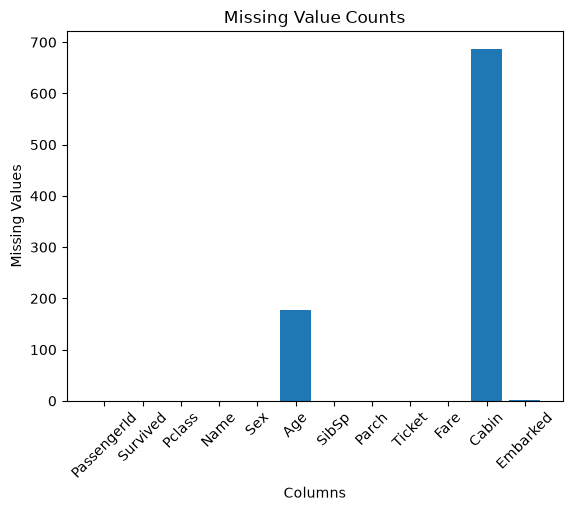

--------------------------------------------------
missing value count :
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
--------------------------------------------------
missing value count :
 PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64
--------------------------------------------------
Number of outliers in Fare: 116


In [75]:
# Find the missing-value count and percentage for every column. 
missing_values = df.isnull().sum()
print('missing value count :\n', missing_values)
print('-' * 50)
print('missing value percentage :\n', missing_values / len(df) * 100)

# Plot missing counts as a bar chart.
print('-' * 50)
plt.bar(missing_values.index, missing_values.values)
plt.title('Missing Value Counts')  
plt.xlabel('Columns')
plt.ylabel('Missing Values')
plt.xticks(rotation=45)
plt.show()

print('-' * 50)

#   Fill missing Age values with the mean Age. Show missing counts before and after.
df['Age'] = df['Age'].fillna(df['Age'].mean())
print('missing value count :\n', df.isnull().sum())
print('-' * 50)

#   Try to fill NaN values by imputing using: mean, median, mode, random value
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Cabin'] = df['Cabin'].fillna('Unknown')
print('missing value count :\n', df.isnull().sum())

print('-' * 50)

#   For Fare, calculate Q1, Q3, IQR, 1.5xIQR bounds, and count the outliers.
Q1= df.Fare.quantile(0.25)
Q3= df.Fare.quantile(0.75)
IQR= Q3 - Q1
lower_bound= Q1 - 1.5 * IQR
upper_bound= Q3 + 1.5 * IQR
outliers= df[(df.Fare < lower_bound) | (df.Fare > upper_bound)]
print('Number of outliers in Fare:', len(outliers))


#### Task 8 - Features and Pivot Table


In [76]:
#   Create FamilySize = SibSp + Parch + 1 and IsAlone = 1 when FamilySize = 1.
df['FamilySize'] = df.SibSp + df.Parch + 1
# making a copy of df : 
df_copy = df.copy()
df_copy['IsAlone'] = np.where(df['FamilySize'] == 1, 1, 0)

#   Create a pivot table: rows=Sex, columns=Pclass, values=mean Survived. 
# Find the highest and lowest groups.
pivot = pd.pivot_table(
    df_copy,
    values='Survived',
    index='Sex',
    columns='Pclass',
    aggfunc='mean'
)

print(pivot)
print('-' * 50)
highest_group = pivot.stack().idxmax()
highest_value = pivot.stack().max()

print("Highest group:", highest_group)
print("Survival rate:", highest_value)

print('-' * 50)
lowest_group = pivot.stack().idxmin()
lowest_value = pivot.stack().min()

print("Lowest group:", lowest_group)
print("Survival rate:", lowest_value)

Pclass         1         2         3
Sex                                 
female  0.968085  0.921053  0.500000
male    0.368852  0.157407  0.135447
--------------------------------------------------
Highest group: ('female', np.int64(1))
Survival rate: 0.9680851063829787
--------------------------------------------------
Lowest group: ('male', np.int64(3))
Survival rate: 0.13544668587896252


#### Task 9 - Visualizations and Observations


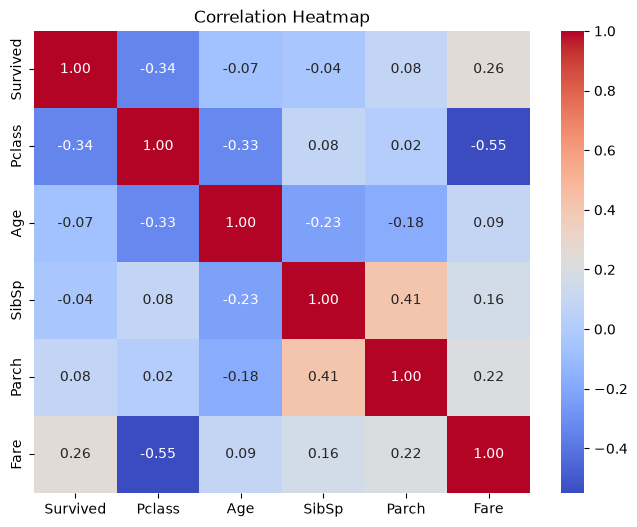

--------------------------------------------------
Strongest positive relationship: ('SibSp', 'Parch')
Correlation: 0.41483769862015624
Strongest negative relationship: ('Pclass', 'Fare')
Correlation: -0.5494996199439076
--------------------------------------------------


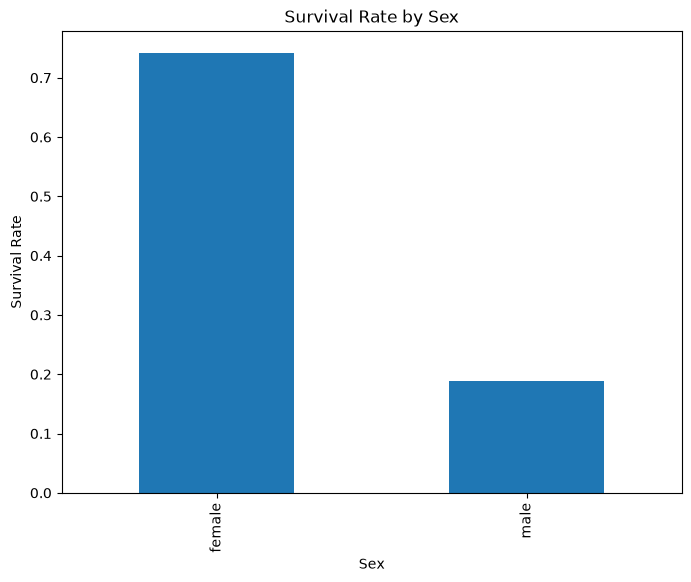

Male survival rate: 18.890814558058924 %
Female survival rate: 74.20382165605095 %
--------------------------------------------------


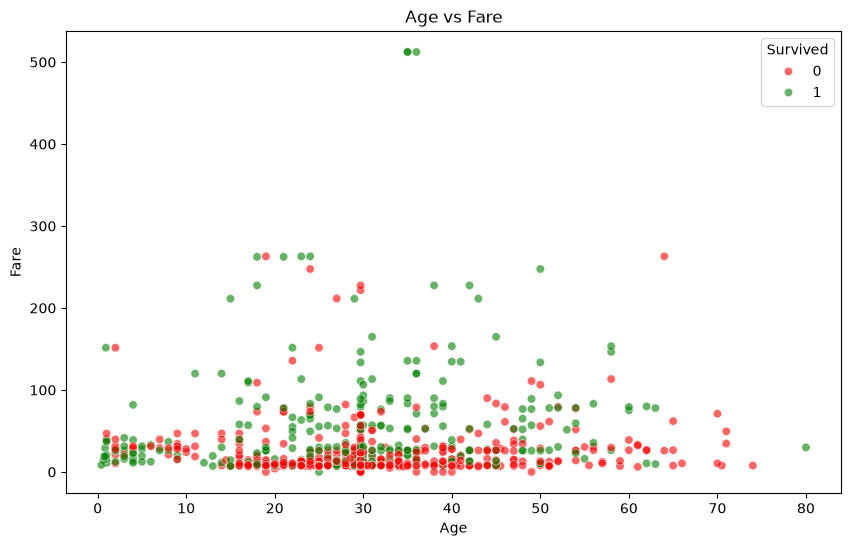

--------------------------------------------------


In [ ]:
# Plot a correlation heatmap for relevant numerical columns. 
# Note the strongest positive and negative relationships.
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

print('-' * 50)

corr_no_diag = corr.copy()
# removing the diagonal as every variable is perfectly correlated with itself
corr_no_diag = corr.copy()

corr_no_diag = corr_no_diag.mask(
    np.eye(corr_no_diag.shape[0], dtype=bool)
)
# once diagonal values are removed we can find the required strongest positive and negative relationships
strongest_positive = corr_no_diag.stack().idxmax()
positive_value = corr_no_diag.stack().max()

print("Strongest positive relationship:", strongest_positive)
print("Correlation:", positive_value)

strongest_negative = corr_no_diag.stack().idxmin()
negative_value = corr_no_diag.stack().min()

print("Strongest negative relationship:", strongest_negative)
print("Correlation:", negative_value)

print('-' * 50)

#   Plot the survival rate by Sex and report the male/female survival rates.
plt.figure(figsize = (8, 6))
df.groupby('Sex')['Survived'].mean().plot(kind='bar')
plt.xlabel('Sex')
plt.ylabel('Survival Rate')
plt.title('Survival Rate by Sex')
plt.show()

print('Male survival rate:', df[df['Sex'] == 'male']['Survived'].mean() * 100 , '%')
print('Female survival rate:', df[df['Sex'] == 'female']['Survived'].mean() * 100 , '%')

print('-' * 50)

#   Plot Age vs Fare and distinguish Survived=0 and Survived=1.
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='Age',
    y='Fare',
    hue='Survived',
    palette={0: 'red', 1: 'green'},
    alpha=0.6
)
plt.xlabel('Age')
plt.ylabel('Fare')
plt.title('Age vs Fare')
plt.show()

print('-' * 50)

#   Write 5-7 short observations supported by your numerical results or plots.

### Observations : 
1. Sex had a strong relationship with survival: female passengers had a 74.20% survival rate compared with only 18.89% for males.
2. Passenger class was strongly associated with survival: 1st-class passengers had a 62.96% survival rate, compared with 47.28% for 2nd class and 24.24% for 3rd class.
3. The combination of Sex and Pclass showed an even stronger difference: female 1st-class passengers had the highest survival rate (96.81%), while male 3rd-class passengers had the lowest (13.54%).
4. Fare was highly skewed and contained outliers: the median Fare was 14.45, while the mean was 32.20, and 116 Fare values were identified as outliers using the IQR method.
5. The strongest correlation was negative between Pclass and Fare (−0.5495), while the strongest positive correlation was between SibSp and Parch (0.4148).
6. Missing data was a major issue for Cabin: 77.10% of Cabin values were missing, compared with 19.87% for Age and only 0.22% for Embarked.